
# Site Frequency Spectrum (SFS) 


## Objectives

1. What is the SFS?
2. What is the neutral expectation for the SFS?
3. How to calculate the SFS & interpret the results



## 1. What is a site frequency spectrum?

For a sample of `n` haploid chromosomes, the **site frequency spectrum** summarizes how many segregating sites have been observed `i` times in the sample; ie the frequency of SNPs in our sample.

For an **unfolded SFS**, the bins are:

- `i = 1`: singleton variants
- `i = 2`: doubletons
- ...
- `i = n-1`: variants at the highest non-fixed frequency


For a **folded SFS**, ancestral and derived states are not known. Counts are folded around the midpoint, so frequency classes `i` and `n-i` are combined.

> **Important:** The SFS is a summary of genome-wide data, not the direct demographic history



## 2. Neutral expectation

Suppose we sample 20 haploid chromosomes. 
Under the standard neutral model, we expect number of sites with derived allele of frequency `i` to be proportional to `1/i`.

### Questions (1)

1. What is the x axis of the SFS?
2. What is the y axis of the SFS?
3. Which should be more common: singletons or variants with frequency 10?
4. What happens to the expected count as allele frequency increases?
5. What change to neutral expectation do you expect to see in population expansion?



<details>
<summary><b>▶ Show Answers</b></summary>

1. sample allele counts (how many haploid chromosomes carry the mutated or derived allele)
    - values: unfolded sfs = 1 to n-1 (n=total number of sampled chromosomes)
    - values: folded sfs = 1 to n/2 (minor allele frequency)
 
    
2. number of sites per frequency category
    
    
3. Singletons are more common,

   e.g. 1 SNP (i=1) → 1/1 = 1

   e.g. 10 SNPs (i=10) → 1/10 = 0.1

    
4. Increase allele frequency, expected count decreases.

    
5. Population expansion (increase Ne) → expect excess rare variants
   (longer branches near tips, accumulate many new mutations in one or
   few individuals).

</details>

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sample size 20 haploid chromosomes
n = 20
# possible segregating sites, 1,2..19
i = np.arange(1, n)

# expect sfs ∝ 1/i
# count 1 = 1/1, count 2 = 1/2 etc
neutral = 1 / i
# normalise by sum to get the relative frequencies (so freq classes add to 1)
neutral = neutral / neutral.sum()

# collect in df
sfs = pd.DataFrame({
    "derived_count": i,
    "relative_expected_frequency": neutral
})

# look at df
sfs.head()


,derived_count,relative_expected_frequency
0,1,0.281870
1,2,0.140935
2,3,0.093957
3,4,0.070467
4,5,0.056374


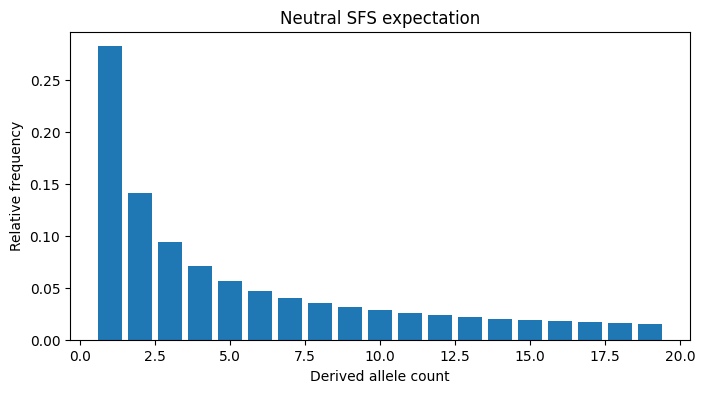

In [4]:
# barplot
plt.figure(figsize=(8, 4))
plt.bar(sfs["derived_count"], sfs["relative_expected_frequency"])
# add labels
plt.xlabel("Derived allele count")
# relative number of sites
plt.ylabel("Relative frequency")
# add title
plt.title("Neutral SFS expectation")
plt.show()



### Questions (2)

4. Under neutrality why do we see more rare variants than common ones?

A. Because mutations are unable to reach high frequency.  
B. Because neutral coalescent trees have longer branch lengths near the tips allowing rare mutations to occur.  
C. Because selection removes all common variants.  
D. Because sequencing errors always create singletons.


<details>
<summary><b>▶ Show Answers</b></summary>

### B

- The branches near the tips of the tree represent recent history and affect only a few individuals. 
- Mathematically, the coalescent model shows that these tip branches are much longer in total than the deep internal branches. 
- These recent branches are longer, so have more time to accumulate random mutations. => we expect an abundance of rare variants that declines predictably as variants become more common

</details>


5. If a site has derived allele count `1` in a sample of 100 haploid chromosomes, it is:

A. A fixed difference  
B. A singleton  
C. A doubleton  
D. A common variant


<details>
<summary><b>▶ Show Answers</b></summary>

### B

- derived count 1 = singleton, (derived count 2 = doubleton etc)
</details>

## 3. Calculate the SFS from simulated data

There are 3 simulated datasets for you to read in, calculate the SFS for them & determine which demography produced them

In [ ]:
%%R

library(vcfR)

# calc sfs
calc_sfs <- function(gt) {
# columns = individuals
    n <- ncol(gt)
# rows = snps
    m <- nrow(gt)   
# calculate row sums (of the snps) 
    allele_counts <- rowSums(gt)
# normalise
    table(allele_counts) / m}

# vcf to sfs
one_scenario<-function(inp){
vcf <- read.vcfR(paste0("/course/kenya2026/harvi/sfs/inputdata/",inp,".vcf.gz"))
ingt <- extract.gt(vcf, element = "GT")

ingt[which(ingt=="0|0")]<-0
ingt[which(ingt=="0|1")]<-1
ingt[which(ingt=="1|0")]<-1
ingt[which(ingt=="1|1")]<-2

ingt <- apply(ingt, 2, as.numeric)

a_sfs<-calc_sfs(ingt)
return(a_sfs)}

scena<-one_scenario("simld_a_for_sfs")
scenb<-one_scenario("simld_b_for_sfs")
scenc<-one_scenario("simld_c_for_sfs")


par(mfrow = c(1, 3))

barplot(scena,col = "darkseagreen" ,xlab = "Derived allele count",ylab = "Proportion of segregating sites",ylim = c(0, max(scena, scenb, scenc)),border = NA)

barplot(scenb,col = "plum",border = NA, xlab = "Derived allele count",ylab = "Proportion of segregating sites",ylim = c(0, max(scena, scenb, scenc)))

barplot(scenc,col = "blue",border = NA, xlab = "Derived allele count",ylab = "Proportion of segregating sites",ylim = c(0, max(scena, scenb, scenc)))

### Questions (3)

1. Which scenario do you think was used to generate each of a,b,c?
2. Describe the differences in the SFS shape for each curve
3. Does the curve for c look unusual? why may this be?

## 4. Calculate the SFS from wildebeest data

Calculate the SFS for wildebeest data & interpret results

In [ ]:
%%R

library(vcfR)
# read in black wildebeest data
vcf <- read.vcfR(paste0("/course/kenya2026/harvi/sfs/inputdata/blackwildebeest_chr1.vcf.gz"))
ingt <- extract.gt(vcf, element = "GT")

ingt <- ingt[complete.cases(ingt), ]

ingt[which(ingt=="0/0")]<-0
ingt[which(ingt=="0/1")]<-1
ingt[which(ingt=="1/0")]<-1
ingt[which(ingt=="1/1")]<-2

ingt <- apply(ingt, 2, as.numeric)

# folded sfs, counts
calc_folded<-function(ingen){
nchr <- ncol(ingen)    
# count alt alleles per site
alt_count <- rowSums(ingen, na.rm = TRUE)
# folding, by taking smaller of the alt or reference allele count
minor_count <- pmin(alt_count, n_chr - alt_count)
    # count how many sites per category
folded_sfs <- table(minor_count)
return(folded_sfs)}

emp1<-calc_folded(ingt)

par(mfrow = c(1, 2))
barplot(emp1, col = "black" ,xlab = "Derived allele count",ylab = "Counts of segregating sites",border = NA)

# look without the 0 sites
emp2 <- emp1[names(emp1) != "0"]
barplot(emp2, col = "black" ,xlab = "Derived allele count",ylab = "Counts of segregating sites",border = NA)




### Questions (4)

1. What is different about the SFS you calculated here for the wildebeest vs the simulated data above? & why do you think we did this differently?
2. What is the difference between the 2 plots??
3. Look at shape of SFS what can you conclude about this population?


<details>
<summary><b>▶ Show Answers</b></summary>

1. folded SFS because we lack information of which allele is ancestral & derived; here we also look at the counts not the proportions
2. we included the 0 category of invariant sites in the left hand plot, we usually don't do this because the 0 category overwhelms the plot & we cannot see the trend in segregating sites
3. flat SFS, potentially strong recent decline


</details>


### Questions (5)

What information is lost when an SFS is folded?

A. The total number of segregating sites  
B. The distinction between low-frequency derived alleles and high-frequency derived alleles  
C. The sample size  
D. All information about genetic variation



<details>
<summary><b>▶ Show Answers</b></summary>

### B


</details>


## 5. From the SFS to demographic inference

In  demographic inference, we can compare the observed SFS to an expected SFS under a demographic model.

A simplified workflow is:

**genomic data → variant filtering → allele counts → SFS → demographic model**

A model might include:

- changes in effective population size through time,
- population splits,
- migration rates





## Questions (6)

### 1. What does SFS bin `i` represent?

A. Number of mutations per chromosome  
B. Number of segregating sites whose derived allele occurs `i` times  
C. Number of chromosomes sampled from population `i`  
D. Number of genes in population `i`


### 2. Under the standard neutral constant-size model, the expected SFS is approximately proportional to:

A. `i`  
B. `i²`  
C. `1/i`  
D. constant for all `i`


### 3. Why fold an SFS?

A. To increase sample size  
B. To handle uncertainty about the ancestral state  
C. To remove all sequencing errors  
D. To estimate recombination directly





<details>
<summary><b>▶ Show Answers</b></summary>

1. B
2. C
3. B


</details>